# Short Straddle

This [strategy](https://www.investopedia.com/terms/s/shortstraddle.asp) involves selling simultaneously the same number of call and put options with the same strike price.

It is profitable if both options expire worthless.

**Caveat: Options are very risky derivatives and, like any other type of financial vehicle, trading options requires due diligence. Transactions shown as examples of trading strategies with options in this notebook are not recommendations.**

In [1]:
from __future__ import print_function

import datetime as dt
import sys

import matplotlib.pyplot as plt
from numpy import zeros

from optionlab import __version__, run_strategy

%matplotlib inline

In [2]:
print("Python version: %s" % sys.version)
print("OptionLab version: %s" % __version__)

Python version: 3.11.9 | packaged by Anaconda, Inc. | (main, Apr 19 2024, 16:40:41) [MSC v.1916 64 bit (AMD64)]
OptionLab version: 1.9.0


The underlying asset is Nvidia stock (ticker: NVDA). The strategy involves selling 100 call and 100 put options with a strike of 170. We collect a premium of 10.05 per option.

In [3]:
stock_price = 168.99
volatility = 0.483
start_date = dt.date(2023, 1, 16)
target_date = dt.date(2023, 2, 17)
interest_rate = 0.045
min_stock = stock_price - round(stock_price * 0.5, 2)
max_stock = stock_price + round(stock_price * 0.5, 2)
strategy = [
    {"type": "call", "strike": 170.0, "premium": 9.9, "n": 100, "action": "sell"},
    {"type": "put", "strike": 170.0, "premium": 10.2, "n": 100, "action": "sell"},
]

inputs = {
    "stock_price": stock_price,
    "start_date": start_date,
    "target_date": target_date,
    "volatility": volatility,
    "interest_rate": interest_rate,
    "min_stock": min_stock,
    "max_stock": max_stock,
    "strategy": strategy,
}

In [4]:
%%time
out = run_strategy(inputs)

CPU times: total: 203 ms
Wall time: 230 ms


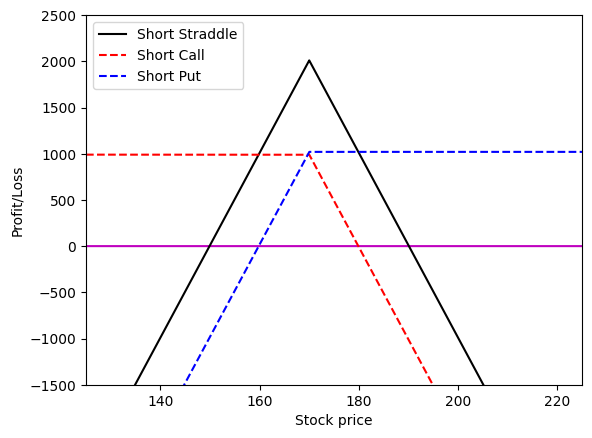

In [5]:
s, pl_total = out.data.stock_price_array, out.data.strategy_profit
leg = []

for i in range(len(strategy)):
    leg.append(out.data.profit[i])

zeroline = zeros(s.shape[0])
plt.xlabel("Stock price")
plt.ylabel("Profit/Loss")
plt.xlim(125, 225)
plt.ylim(-1500, 2500)
plt.plot(s, zeroline, "m-")
plt.plot(s, pl_total, "k-", label="Short Straddle")
plt.plot(s, leg[0], "r--", label="Short Call")
plt.plot(s, leg[1], "b--", label="Short Put")
plt.legend(loc="upper left")

In [6]:
print(out)

Probability of profit: 0.5741738111649408
Profit ranges: [(149.9001, 190.09990000000002)]
Expected profit if profitable: 1053.2724099878124
Expected loss if unprofitable: -1439.894978692975
Per leg cost: [990.0, 1019.9999999999999]
Strategy cost: 2010.0
Minimum return in the domain: -6541.0
Maximum return in the domain: 2010.0
Implied volatility: [0.4826500896570693, 0.48346942266415105]
In the money probability: [0.465831136209786, 0.534168863790214]
Probability of touch: [0.9661799112521838, 1.0]
Delta: [-0.525237550169406, 0.474762449830594]
Gamma: [0.015806160944019643, 0.015806160944019643]
Theta: [0.22301627833773927, 0.19278895912917046]
Vega: [0.20763771616023433, 0.20763771616023433]
Rho: [-0.07509774107468528, 0.0861146280376816]

